## EDA
Я выбрал датасет с данными о пингвинах https://www.kaggle.com/datasets/satyajeetrai/palmer-penguins-dataset-for-eda, там вроде как написано, что он хорошо подходит для EDA.

## Обзор данных
Просто вывод в понятном текстовом виде и проверки адекватности типов данных.

In [2]:
import numpy as np
import pandas as pd

df = pd.read_csv('penguins.csv')

df.head()

,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [3]:
df.tail()

,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
339,339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009
343,343,Chinstrap,Dream,50.2,18.7,198.0,3775.0,female,2009


In [4]:
df.shape

(344, 9)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 344 non-null    int64  
 1   species            344 non-null    str    
 2   island             344 non-null    str    
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    str    
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), str(3)
memory usage: 24.3 KB


In [6]:
df.describe()

,id,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,344.000000,342.000000,342.000000,342.000000,342.000000,344.000000
mean,171.500000,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,99.448479,5.459584,1.974793,14.061714,801.954536,0.818356
min,0.000000,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,85.750000,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,171.500000,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,257.250000,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,343.000000,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [7]:
df.describe(include=str)

,species,island,sex
count,344,344,333
unique,3,3,2
top,Adelie,Biscoe,male
freq,152,168,168


In [8]:
df.isnull().sum()

id                    0
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

^В следующем пункте нужно будет заполнить эти пропуски^

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

id                     int64
species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
year                   int64
dtype: object

## Пропуски и очистка
Теперь нужно заполнить пропуски, выявленные на предыдущем этапе. Для начала решим заполнять ли нам пропуски или все же удалять строки с неполными данными. Т.к. данных с пропусками не много в общем объеме, где-то

In [11]:

print(df.shape[0] - df.dropna().shape[0])
print('в процентах:')
print((df.shape[0] - df.dropna().shape[0]) / df.shape[0] * 100)

11
в процентах:
3.1976744186046515


то можно сделать вывод, что лучше будет использовать fillna, т.к. оно не сильно повлияет на конечный результат (наверное). Заполнять пробелы  в bill_length_mm и bill_depth_mm буду средним, т.к. там вроде как что то хотя бы немного похожее на нормальное распределение, в flipper_length_mm и body_mass_g заполнять буду медианным значением, т.к эти колонки (как видно на kaggle) вроде как имеют небольшие выбросы.
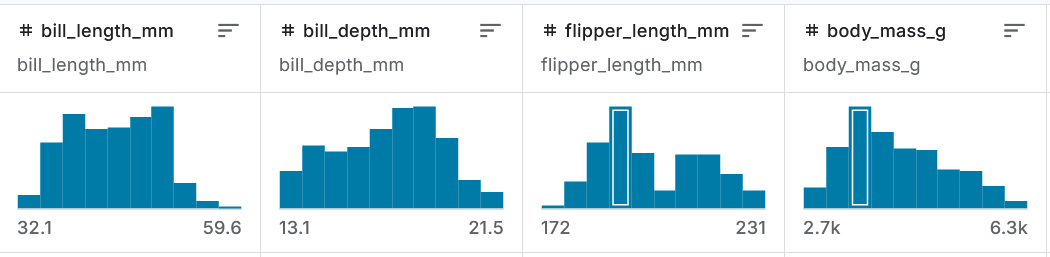

In [12]:
df_filled = df.fillna({
    "bill_depth_mm" : df['bill_depth_mm'].mean(), 
    "bill_length_mm" : df['bill_length_mm'].mean(),
    "flipper_length_mm" : df['flipper_length_mm'].median(),
    "body_mass_g" : df['body_mass_g'].median()
    })
df_filled.head()

,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,0,Adelie,Torgersen,39.10000,18.70000,181.0,3750.0,male,2007
1,1,Adelie,Torgersen,39.50000,17.40000,186.0,3800.0,female,2007
2,2,Adelie,Torgersen,40.30000,18.00000,195.0,3250.0,female,2007
3,3,Adelie,Torgersen,43.92193,17.15117,197.0,4050.0,NaN,2007
4,4,Adelie,Torgersen,36.70000,19.30000,193.0,3450.0,female,2007


Поле sex заполним модой, потому что это категориальное поле.

In [13]:
mode = df['sex'].mode()
print('мода поля sex: ')
print(mode)
df_filled.fillna(mode[0], inplace=True)

мода поля sex: 
0    male
Name: sex, dtype: str


,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,0,Adelie,Torgersen,39.10000,18.70000,181.0,3750.0,male,2007
1,1,Adelie,Torgersen,39.50000,17.40000,186.0,3800.0,female,2007
2,2,Adelie,Torgersen,40.30000,18.00000,195.0,3250.0,female,2007
3,3,Adelie,Torgersen,43.92193,17.15117,197.0,4050.0,male,2007
4,4,Adelie,Torgersen,36.70000,19.30000,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...,...
339,339,Chinstrap,Dream,55.80000,19.80000,207.0,4000.0,male,2009
340,340,Chinstrap,Dream,43.50000,18.10000,202.0,3400.0,female,2009
341,341,Chinstrap,Dream,49.60000,18.20000,193.0,3775.0,male,2009
342,342,Chinstrap,Dream,50.80000,19.00000,210.0,4100.0,male,2009


Теперь проверим заполнились ли поля (для наглядности)

In [14]:
df_filled.isnull().sum()

id                   0
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
year                 0
dtype: int64

## Расширенная статистика
Просчитаем min, max, mean, median, mode для числовых колонок

In [15]:
df_numeric = df_filled.select_dtypes(include=['number'])
df_numeric.min()

id                      0.0
bill_length_mm         32.1
bill_depth_mm          13.1
flipper_length_mm     172.0
body_mass_g          2700.0
year                 2007.0
dtype: float64

In [16]:
df_numeric.max()

id                    343.0
bill_length_mm         59.6
bill_depth_mm          21.5
flipper_length_mm     231.0
body_mass_g          6300.0
year                 2009.0
dtype: float64

In [17]:
df_numeric.mean()

id                    171.500000
bill_length_mm         43.921930
bill_depth_mm          17.151170
flipper_length_mm     200.892442
body_mass_g          4200.872093
year                 2008.029070
dtype: float64

In [18]:
df_numeric.median()

id                    171.50
bill_length_mm         44.25
bill_depth_mm          17.30
flipper_length_mm     197.00
body_mass_g          4050.00
year                 2008.00
dtype: float64

In [19]:
df_numeric.mode().head(1)

,id,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,0,41.1,17.0,190.0,3800.0,2009.0


Теперь просчитаем процентили 5, 25, 50, 75, 95 для всех столбцов

In [20]:
df_numeric.quantile([0.05, 0.25, 0.5, 0.75, 0.95])

,id,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0.05,17.15,35.700,13.9,181.0,3150.0,2007.0
0.25,85.75,39.275,15.6,190.0,3550.0,2007.0
0.50,171.50,44.250,17.3,197.0,4050.0,2008.0
0.75,257.25,48.500,18.7,213.0,4750.0,2009.0
0.95,325.85,51.985,20.0,225.0,5650.0,2009.0


Посчитаем дисперсию (varity), асимметрию (skew) и эксцесс (kurtosis).

In [21]:
df_numeric.var()

id                     9890.000000
bill_length_mm           29.633252
bill_depth_mm             3.877069
flipper_length_mm       196.667698
body_mass_g          639514.543359
year                      0.669706
dtype: float64

In [22]:
df_numeric.skew()

id                   0.000000
bill_length_mm       0.053272
bill_depth_mm       -0.143880
flipper_length_mm    0.351218
body_mass_g          0.474832
year                -0.053728
dtype: float64

In [23]:
df_numeric.kurtosis()

id                  -1.200000
bill_length_mm      -0.863480
bill_depth_mm       -0.894497
flipper_length_mm   -0.971878
body_mass_g         -0.704620
year                -1.504937
dtype: float64

## Feature Encoding
Для этого жатасета лучше всего, как мне кажется использовать one-hot-encoding т.к. он не большой.

In [24]:
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder = OneHotEncoder(sparse_output=False)

df_to_encode = df_filled.select_dtypes(include=str)
df_encoded = pd.DataFrame(one_hot_encoder.fit_transform(df_to_encode))
feature_names = one_hot_encoder.get_feature_names_out(df_to_encode.columns)

df_encoded.columns = feature_names
df_encoded.head()


,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen,sex_female,sex_male
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [25]:
df_encoded = df_encoded.join(df_filled.select_dtypes(exclude=str))
df_encoded.head()

,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen,sex_female,sex_male,id,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0,39.10000,18.70000,181.0,3750.0,2007
1,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1,39.50000,17.40000,186.0,3800.0,2007
2,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,2,40.30000,18.00000,195.0,3250.0,2007
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,3,43.92193,17.15117,197.0,4050.0,2007
4,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,4,36.70000,19.30000,193.0,3450.0,2007


Итого мы имеем датафреймы до и после:

In [26]:
print('до:')
print(df_filled.head())
print('после:')
print(df_encoded.head())

до:
   id species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0   0  Adelie  Torgersen        39.10000       18.70000              181.0   
1   1  Adelie  Torgersen        39.50000       17.40000              186.0   
2   2  Adelie  Torgersen        40.30000       18.00000              195.0   
3   3  Adelie  Torgersen        43.92193       17.15117              197.0   
4   4  Adelie  Torgersen        36.70000       19.30000              193.0   

   body_mass_g     sex  year  
0       3750.0    male  2007  
1       3800.0  female  2007  
2       3250.0  female  2007  
3       4050.0    male  2007  
4       3450.0  female  2007  
после:
   species_Adelie  species_Chinstrap  species_Gentoo  island_Biscoe  \
0             1.0                0.0             0.0            0.0   
1             1.0                0.0             0.0            0.0   
2             1.0                0.0             0.0            0.0   
3             1.0                0.0             0

Теперь добавим новые фичи. Создадим фичу bill_area (площадь клюва) и фичу flipper_mass_ratio (соотношение длинны плавников к массе пингвина).

In [27]:
df_encoded['bill_area_mm2'] = df_encoded['bill_length_mm'] * df_encoded['bill_depth_mm']
df_encoded['flipper_mass_ratio_mm_g'] = df_encoded['flipper_length_mm'] * df_encoded['body_mass_g']

df_encoded.head()

,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen,sex_female,sex_male,id,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year,bill_area_mm2,flipper_mass_ratio_mm_g
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0,39.10000,18.70000,181.0,3750.0,2007,731.170000,678750.0
1,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1,39.50000,17.40000,186.0,3800.0,2007,687.300000,706800.0
2,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,2,40.30000,18.00000,195.0,3250.0,2007,725.400000,633750.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,3,43.92193,17.15117,197.0,4050.0,2007,753.312467,797850.0
4,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,4,36.70000,19.30000,193.0,3450.0,2007,708.310000,665850.0


## Визуализация
Для начала визуализируем распределения данных, для этого нарисуем гистограммы.

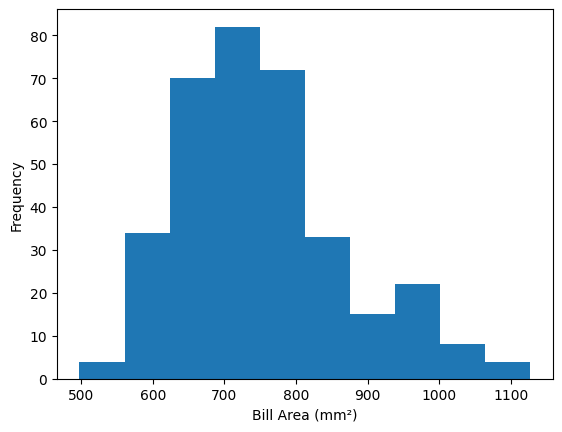

In [63]:
from matplotlib import pyplot as plt
import seaborn as sb
import plotly

plt.hist(df_encoded['bill_area_mm2'])
plt.xlabel('Bill Area (mm²)')
plt.ylabel('Frequency')
plt.show()

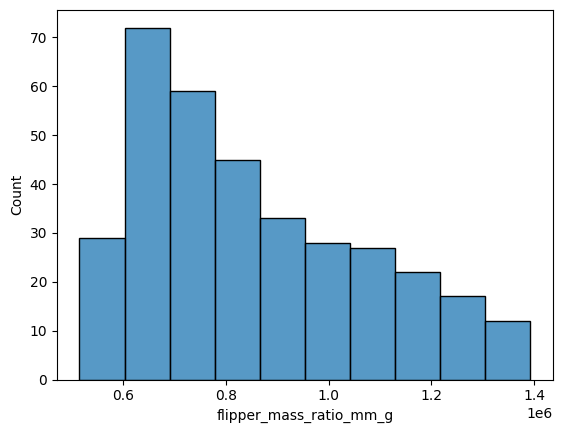

In [64]:
sb.histplot(df_encoded['flipper_mass_ratio_mm_g'])
plt.show()

Теперь построим scatter plot.

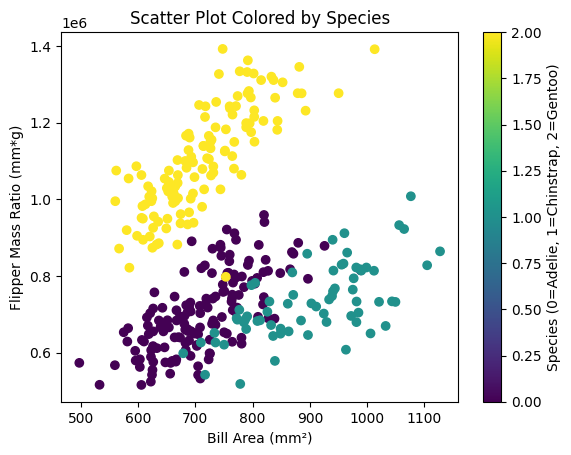

In [56]:
plt.scatter(df_encoded['bill_area_mm2'], df_encoded['flipper_mass_ratio_mm_g'], c=df_filled['species'].astype('category').cat.codes, cmap='viridis')
plt.colorbar(label='Species (0=Adelie, 1=Chinstrap, 2=Gentoo)')
plt.xlabel('Bill Area (mm²)')
plt.ylabel('Flipper Mass Ratio (mm*g)')
plt.title('Scatter Plot Colored by Species')
plt.show()

Попробуем box plot.

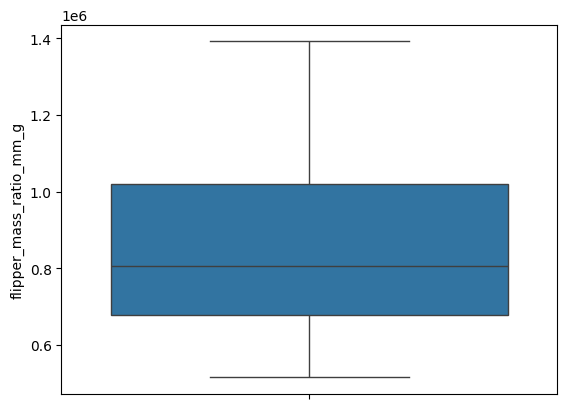

In [65]:
sb.boxplot(df_encoded['flipper_mass_ratio_mm_g'])
plt.show()

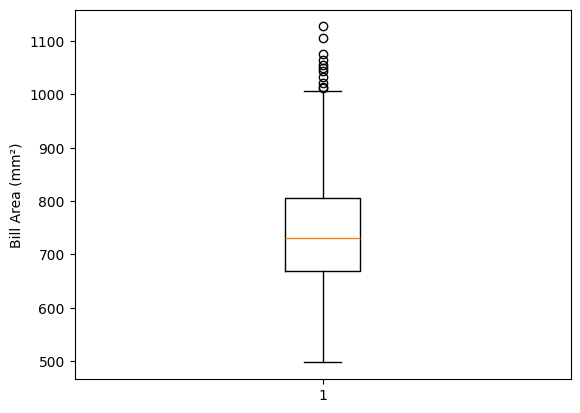

In [66]:
plt.boxplot(df_encoded['bill_area_mm2'])
plt.ylabel('Bill Area (mm²)')
plt.show()

Ну и наконец heatmap.

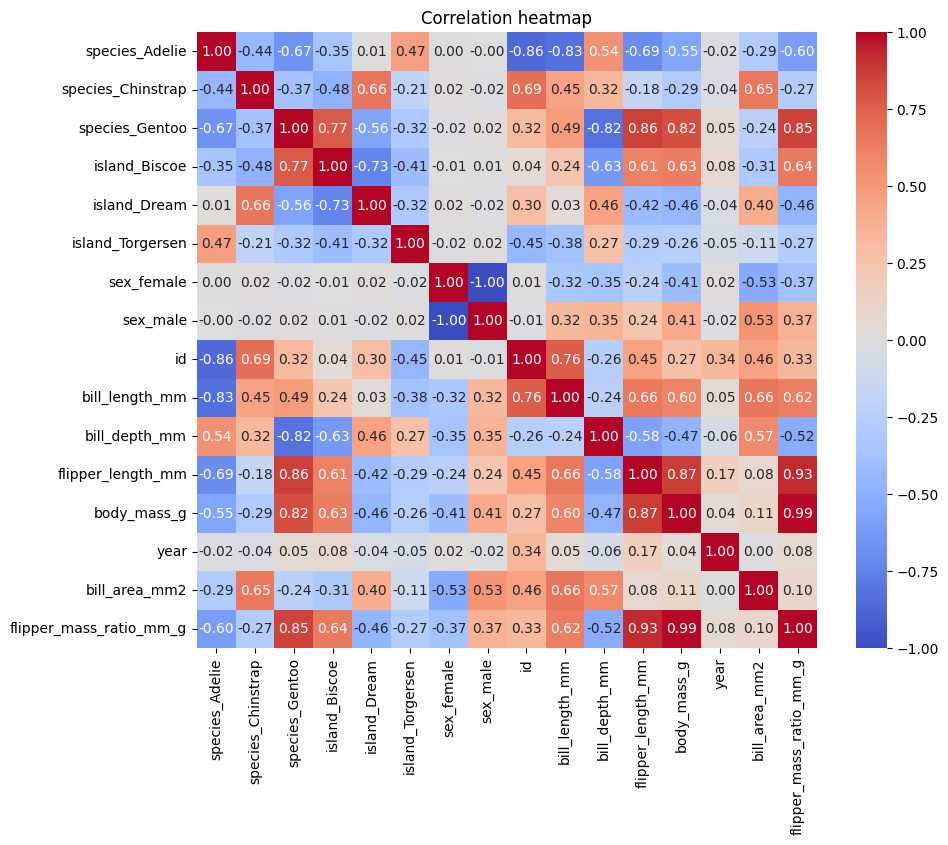

In [78]:
plt.figure(figsize=(10, 8))
sb.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation heatmap")
plt.show()